#### P2-05
# Univariate Exploratory Data Analysis
#### M2 - Amri B.S.M
#### IT24102955

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

In [3]:
!pip install -q s3fs

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.6/102.6 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 221.7/221.7 kB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.0/16.0 MB 63.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
datasets 4.8.5 requires fsspec[http]<=2026.2.0,>=2023.1.0, but you have fsspec 2026.9.0 which is incompatible.
gcsfs 2025.12.0 requires fsspec==2025.12.0, but you have fsspec 2026.9.0 which is incompatible.


In [4]:
!pip install -q --force-reinstall "fsspec==2025.12.0" "s3fs==2025.12.0"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 111.6/111.6 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 201.4/201.4 kB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.3/87.3 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 42.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.5/67.5 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.3/14.3 MB 66.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 234.4/234.4 kB 12.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 336.2/336.2 kB 12.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 234.3/234.3 kB 13.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 229.9/229.9 kB 13.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.1/88.1 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.0/117.0 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 

In [1]:
import pandas as pd

df = pd.read_csv(
    "s3://y3s1-ml-datasets/preprocessed/hotel_bookings_preprocessed.csv"
)

df.shape

(86940, 33)

In [18]:
if "Unnamed: 0" in df.columns:
    df.drop(columns=["Unnamed: 0"], inplace=True)

print("Dataset shape:", df.shape)

Dataset shape: (86940, 32)


## 1. Target Variable Distribution

The target variable `is_canceled` indicates whether a hotel booking was cancelled.

- `0` = Not Cancelled
- `1` = Cancelled

This section examines the class distribution before analysing the remaining variables.

In [2]:
target_counts = df["is_canceled"].value_counts().sort_index()
target_percentages = df["is_canceled"].value_counts(normalize=True).sort_index() * 100

target_summary = pd.DataFrame({
    "Count": target_counts,
    "Percentage": target_percentages.round(2)
})

target_summary

,Count,Percentage
is_canceled,,
0,62953,72.41
1,23987,27.59


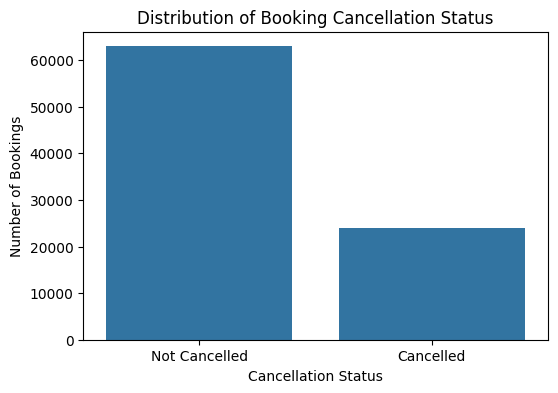

In [5]:
plt.figure(figsize=(6, 4))

sns.countplot(
    data=df,
    x="is_canceled"
)

plt.title("Distribution of Booking Cancellation Status")
plt.xlabel("Cancellation Status")
plt.ylabel("Number of Bookings")
plt.xticks([0, 1], ["Not Cancelled", "Cancelled"])

plt.show()

## 2. Numerical Variable Analysis

This section examines the distribution, central tendency, spread, skewness, and potential outliers of numerical variables.

The purpose is to identify unusual distributions or values that may require attention during the preprocessing stage.

In [6]:
numerical_cols = [
    "lead_time",
    "stays_in_weekend_nights",
    "stays_in_week_nights",
    "adults",
    "children",
    "babies",
    "previous_cancellations",
    "previous_bookings_not_canceled",
    "booking_changes",
    "days_in_waiting_list",
    "adr",
    "required_car_parking_spaces",
    "total_of_special_requests"
]

In [7]:
df[numerical_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
lead_time,86940.0,80.193375,86.100147,0.00,12.00,50.0,125.0,737.0
stays_in_weekend_nights,86940.0,1.007396,1.028763,0.00,0.00,1.0,2.0,16.0
stays_in_week_nights,86940.0,2.628744,2.043753,0.00,1.00,2.0,4.0,41.0
adults,86940.0,1.878525,0.625860,0.00,2.00,2.0,2.0,55.0
children,86940.0,0.139211,0.456786,0.00,0.00,0.0,0.0,10.0
babies,86940.0,0.010835,0.113592,0.00,0.00,0.0,0.0,10.0
previous_cancellations,86940.0,0.030228,0.369574,0.00,0.00,0.0,0.0,26.0
previous_bookings_not_canceled,86940.0,0.176708,1.717885,0.00,0.00,0.0,0.0,72.0
booking_changes,86940.0,0.271854,0.728090,0.00,0.00,0.0,0.0,21.0
days_in_waiting_list,86940.0,0.753497,10.041816,0.00,0.00,0.0,0.0,391.0


In [8]:
skewness = df[numerical_cols].skew().sort_values(ascending=False)

skewness

,0
previous_cancellations,34.375122
babies,21.184554
previous_bookings_not_canceled,20.888896
adults,20.022263
days_in_waiting_list,19.345433
adr,11.005526
booking_changes,5.549438
required_car_parking_spaces,3.517166
children,3.455062
stays_in_week_nights,2.511225


In [9]:
skewness_df = pd.DataFrame({
    "Skewness": skewness
})

skewness_df["Interpretation"] = skewness_df["Skewness"].apply(
    lambda x: "Highly Right-Skewed" if x > 1
    else "Moderately Right-Skewed" if x > 0.5
    else "Highly Left-Skewed" if x < -1
    else "Moderately Left-Skewed" if x < -0.5
    else "Approximately Symmetric"
)

skewness_df

,Skewness,Interpretation
previous_cancellations,34.375122,Highly Right-Skewed
babies,21.184554,Highly Right-Skewed
previous_bookings_not_canceled,20.888896,Highly Right-Skewed
adults,20.022263,Highly Right-Skewed
days_in_waiting_list,19.345433,Highly Right-Skewed
adr,11.005526,Highly Right-Skewed
booking_changes,5.549438,Highly Right-Skewed
required_car_parking_spaces,3.517166,Highly Right-Skewed
children,3.455062,Highly Right-Skewed
stays_in_week_nights,2.511225,Highly Right-Skewed


### Skewness Interpretation

A skewness value close to 0 indicates an approximately symmetric distribution.

- Skewness greater than 1 indicates strong positive or right skewness.
- Skewness between 0.5 and 1 indicates moderate positive skewness.
- Skewness less than -1 indicates strong negative or left skewness.
- Skewness between -0.5 and -1 indicates moderate negative skewness.

Highly skewed variables will be documented for consideration during preprocessing rather than transformed at this stage.

### 2.1 Distribution of Numerical Variables

Histograms are used to examine the shape and spread of each numerical variable. This helps identify skewed distributions, concentration around particular values, and possible extreme observations.

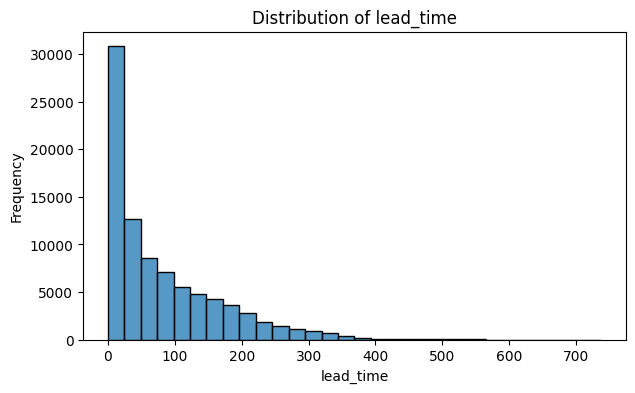

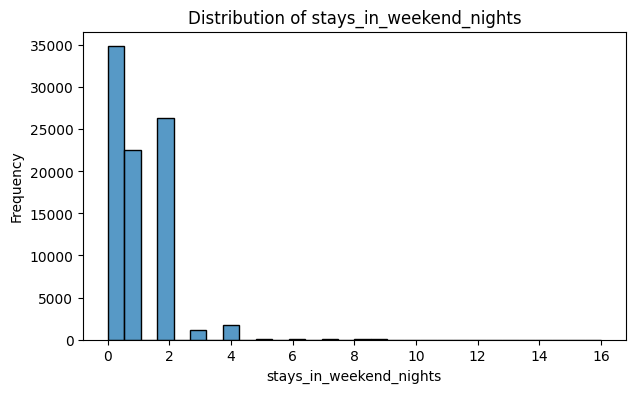

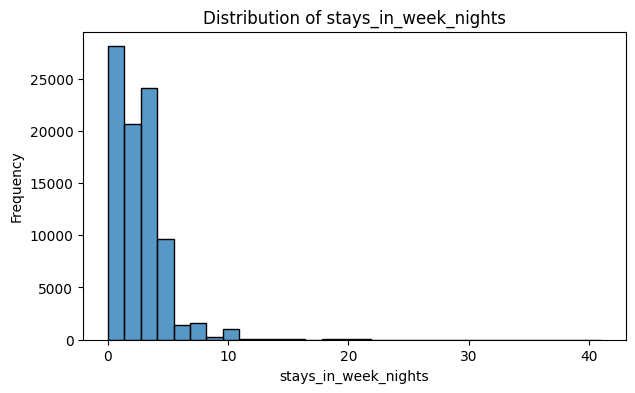

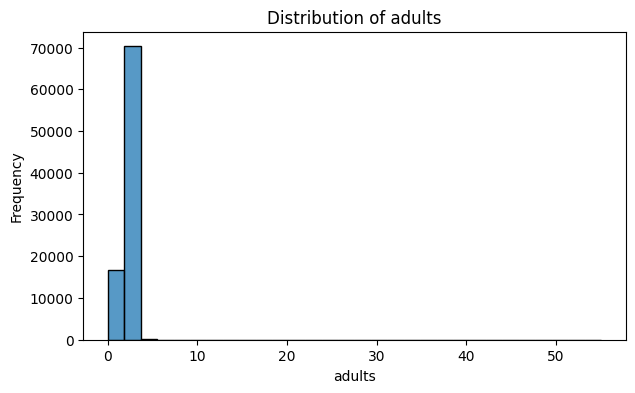

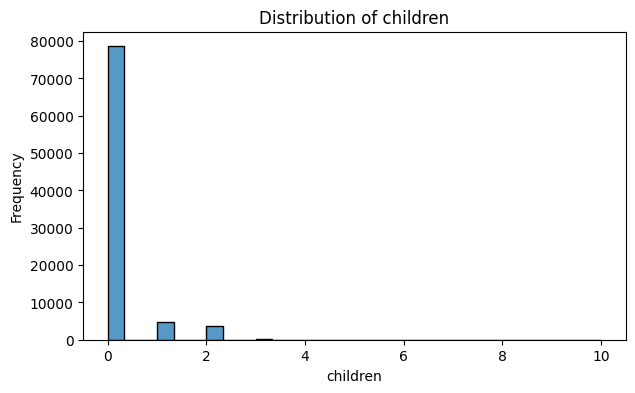

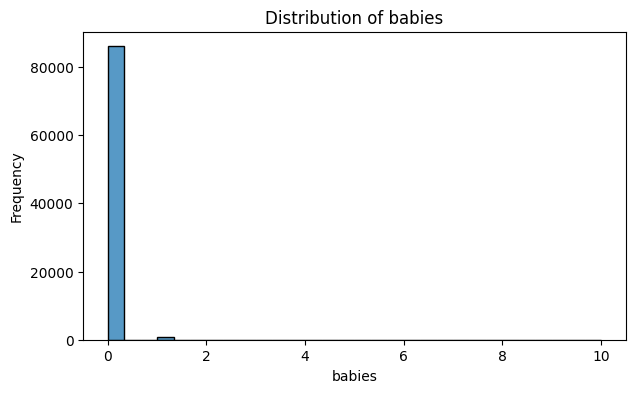

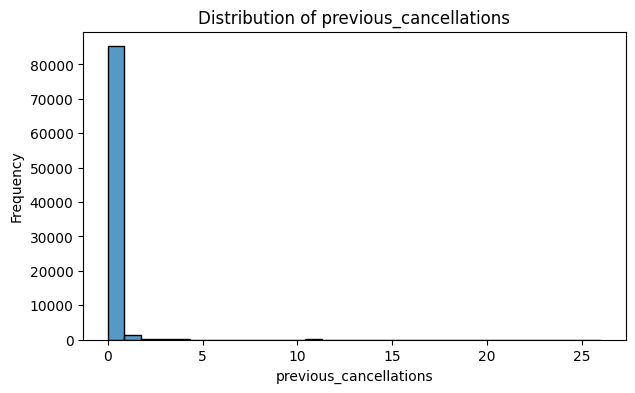

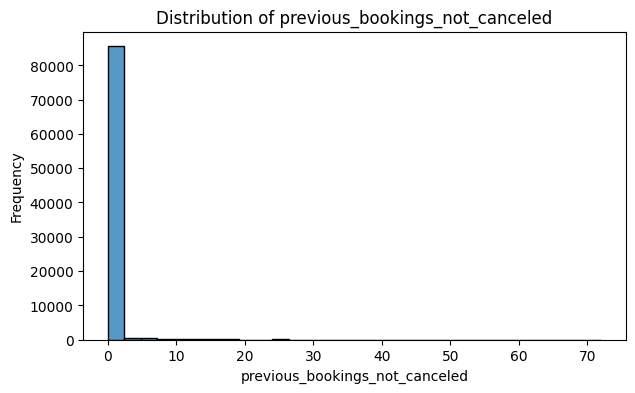

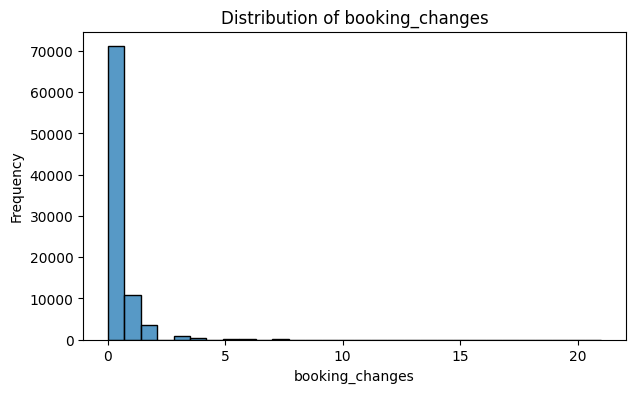

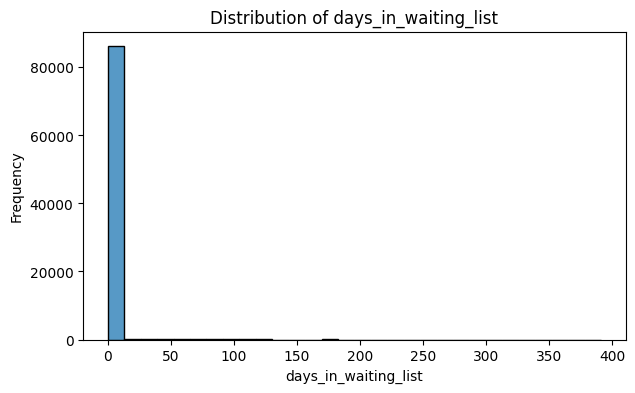

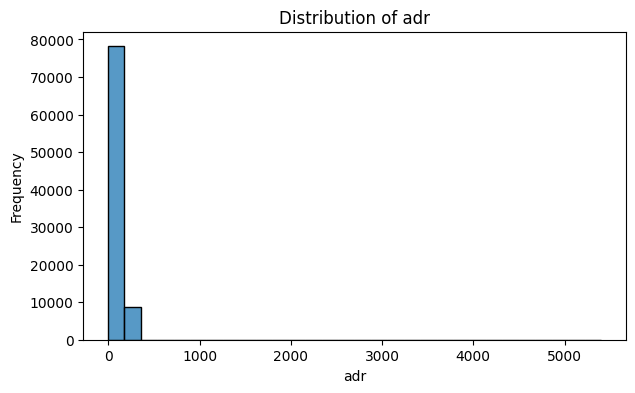

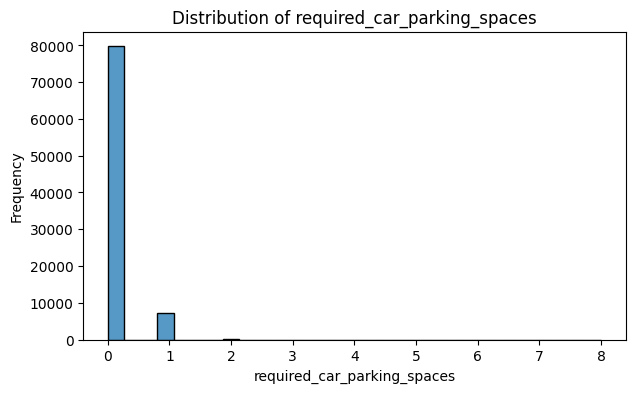

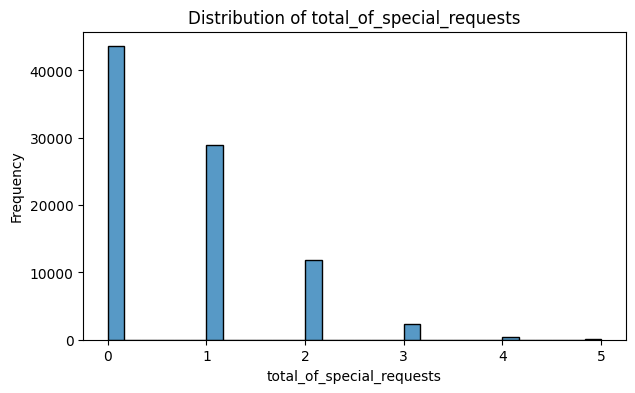

In [19]:
for col in numerical_cols:
    plt.figure(figsize=(7, 4))

    sns.histplot(
    data=df,
    x=col,
    bins=30
)

    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")

    plt.show()

### Histogram Findings

The numerical variables generally exhibit positively skewed distributions. Several count-based variables, including `previous_cancellations`, `previous_bookings_not_canceled`, `babies`, and `days_in_waiting_list`, are strongly concentrated at zero with relatively few large observations.

`lead_time` also shows a long right tail, while `adr` contains particularly extreme values compared with its main distribution. The `adults` variable also contains unusually large observations relative to the majority of bookings.

These observations will be investigated using boxplots before determining whether any values require treatment during preprocessing.

### 2.2 Potential Outliers in Numerical Variables

Boxplots are used to identify observations that fall substantially outside the central distribution of each numerical variable.

Values identified by a boxplot are treated as potential outliers only. No records are removed or modified during this EDA stage.

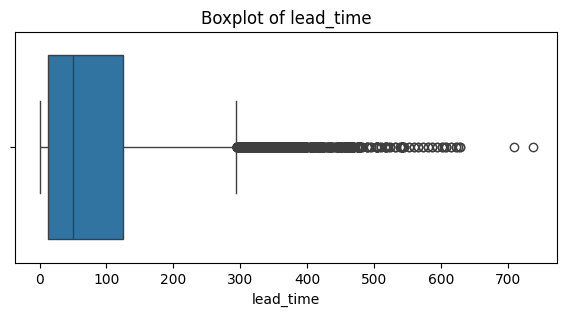

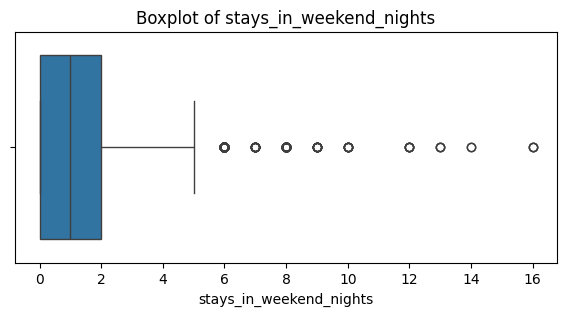

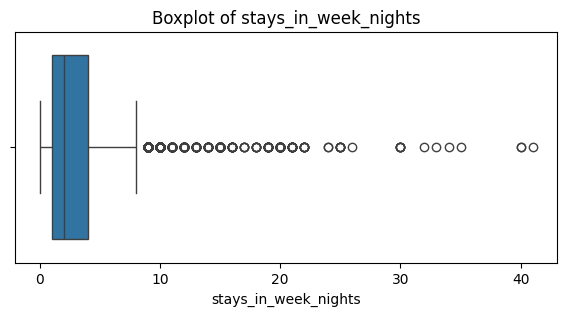

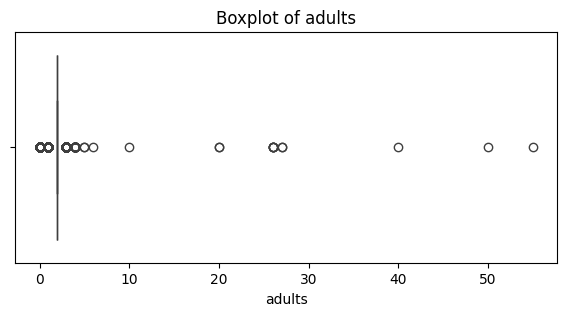

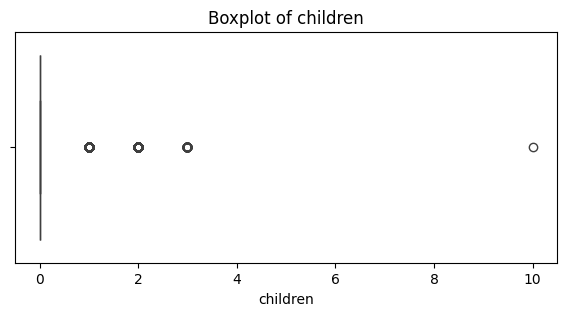

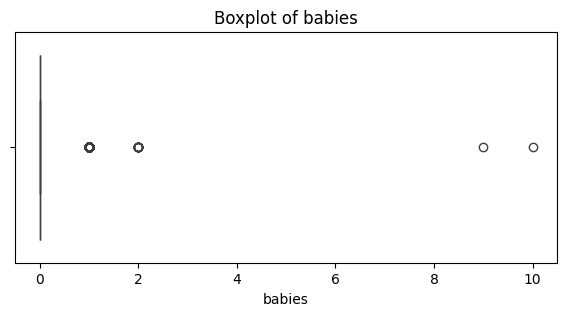

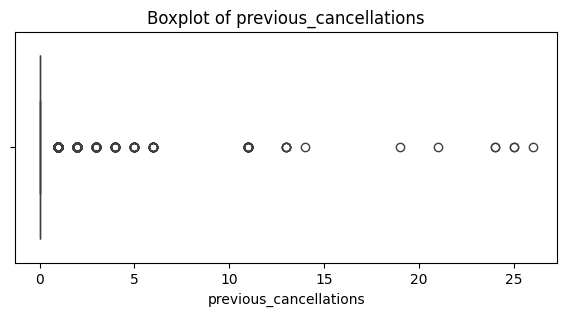

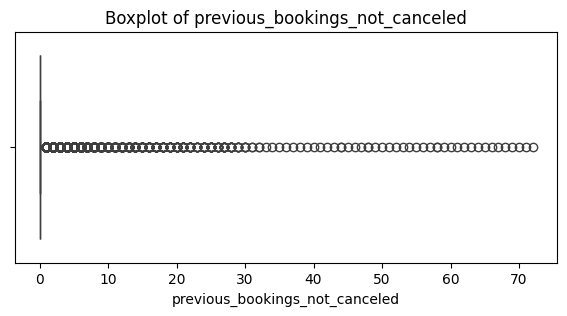

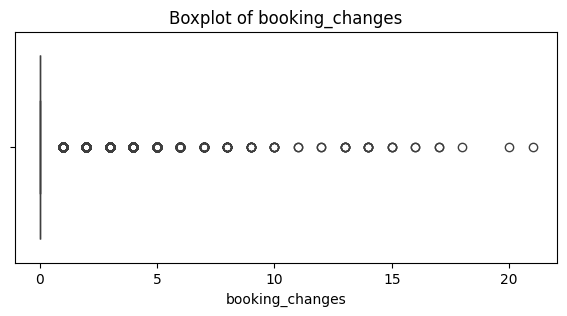

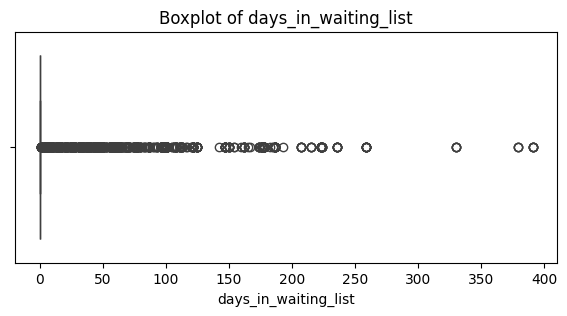

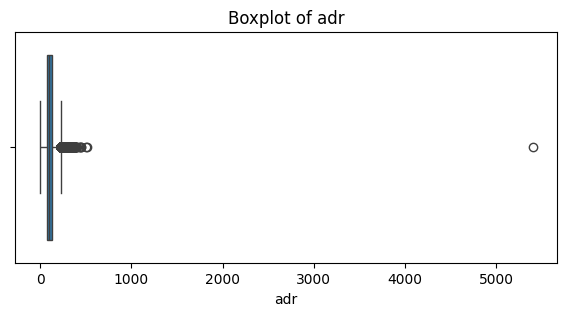

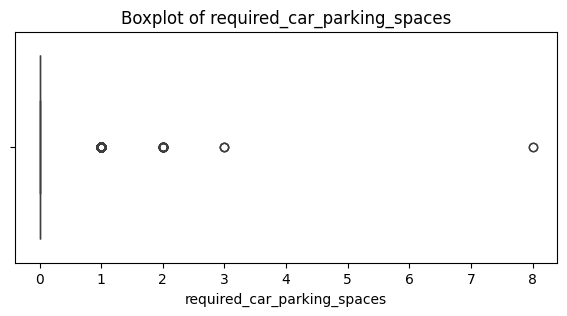

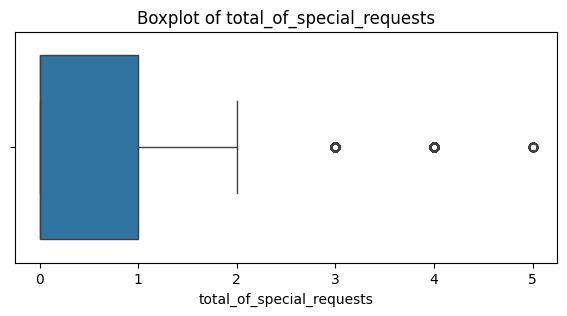

In [11]:
for col in numerical_cols:
    plt.figure(figsize=(7, 3))

    sns.boxplot(
        data=df,
        x=col
    )

    plt.title(f"Boxplot of {col}")
    plt.xlabel(col)

    plt.show()

### Boxplot Findings

The boxplots confirm that several numerical variables contain observations outside the interquartile range. However, these values should not automatically be treated as invalid records because many of the variables are highly skewed or zero-inflated.

`lead_time` contains many high values above approximately 300 days. Although these are statistical outliers, long advance bookings are possible and therefore require further investigation rather than automatic removal.

`stays_in_weekend_nights` and `stays_in_week_nights` contain a small number of unusually long stays. Most bookings involve short stays, while some extend substantially beyond the typical range.

The `adults` variable contains particularly unusual values, including bookings with no adults and some records with very large numbers of adults. These observations should be investigated during preprocessing.

The `children` and `babies` variables are strongly concentrated at zero. Because their quartiles are close to zero, even normal values such as one or two children may appear as boxplot outliers. However, very large values such as approximately 10 children or 9 to 10 babies may require validation.

`previous_cancellations`, `previous_bookings_not_canceled`, `booking_changes`, and `days_in_waiting_list` are also heavily concentrated around zero. Their higher values may represent genuine customer history or unusual bookings rather than data errors.

The `adr` variable contains one particularly extreme observation above 5,000, while the descriptive statistics also identified a negative minimum value. These values require further investigation.

`required_car_parking_spaces` is mostly zero or one, but a very small number of bookings contain much larger values.

`total_of_special_requests` ranges from zero to five. Higher values are statistically uncommon but remain plausible because the variable represents a count of requests.

No observations are removed during this EDA stage. Potentially suspicious values will be documented for investigation during preprocessing.

### 2.3 Investigation of Suspicious Numerical Values

The boxplots identified several extreme observations that may represent either legitimate rare bookings or data quality issues.

This section examines the most suspicious numerical values in more detail before any preprocessing decision is made.

In [12]:
columns_to_check = [
    "adults",
    "children",
    "babies",
    "days_in_waiting_list",
    "adr",
    "required_car_parking_spaces"
]

for col in columns_to_check:
    print(f"\n--- {col} ---")
    print("Minimum:", df[col].min())
    print("Maximum:", df[col].max())

    print("\nHighest values and frequencies:")
    print(
        df[col]
        .value_counts()
        .sort_index(ascending=False)
        .head(10)
    )


--- adults ---
Minimum: 0
Maximum: 55

Highest values and frequencies:
adults
55     1
50     1
40     1
27     2
26     5
20     2
10     1
6      1
5      2
4     60
Name: count, dtype: int64

--- children ---
Minimum: 0.0
Maximum: 10.0

Highest values and frequencies:
children
10.0        1
3.0        75
2.0      3591
1.0      4686
0.0     78587
Name: count, dtype: int64

--- babies ---
Minimum: 0
Maximum: 10

Highest values and frequencies:
babies
10        1
9         1
2        14
1       895
0     86029
Name: count, dtype: int64

--- days_in_waiting_list ---
Minimum: 0
Maximum: 391

Highest values and frequencies:
days_in_waiting_list
391     5
379     3
330     4
259     9
236     7
224     5
223    10
215     4
207     5
193     1
Name: count, dtype: int64

--- adr ---
Minimum: -6.38
Maximum: 5400.0

Highest values and frequencies:
adr
5400.00    1
510.00     1
508.00     1
451.50     1
450.00     1
437.00     1
426.25     1
402.00     1
397.38     1
392.00     2
Name: count,

In [13]:
print("Bookings with 0 adults:")
print((df["adults"] == 0).sum())

print("\nBookings with more than 10 adults:")
print((df["adults"] > 10).sum())

print("\nBookings with more than 5 children:")
print((df["children"] > 5).sum())

print("\nBookings with more than 5 babies:")
print((df["babies"] > 5).sum())

Bookings with 0 adults:
380

Bookings with more than 10 adults:
12

Bookings with more than 5 children:
1

Bookings with more than 5 babies:
2


In [14]:
unusual_guest_records = df[
    (df["adults"] == 0) |
    (df["adults"] > 10) |
    (df["children"] > 5) |
    (df["babies"] > 5)
]

unusual_guest_records[
    [
        "hotel",
        "adults",
        "children",
        "babies",
        "customer_type",
        "market_segment",
        "distribution_channel"
    ]
]

,hotel,adults,children,babies,customer_type,market_segment,distribution_channel
319,Resort Hotel,2,10.0,0,Contract,Offline TA/TO,TA/TO
1454,Resort Hotel,40,0.0,0,Group,Direct,Direct
1502,Resort Hotel,26,0.0,0,Group,Offline TA/TO,TA/TO
1557,Resort Hotel,50,0.0,0,Group,Direct,Direct
1663,Resort Hotel,26,0.0,0,Group,Offline TA/TO,TA/TO
...,...,...,...,...,...,...,...
85080,City Hotel,0,2.0,0,Transient,Online TA,TA/TO
85139,City Hotel,0,2.0,0,Transient,Online TA,TA/TO
85166,City Hotel,0,2.0,0,Transient,Online TA,TA/TO
85291,City Hotel,0,2.0,0,Transient,Online TA,TA/TO


In [15]:
print("Negative ADR records:")
print((df["adr"] < 0).sum())

print("\nADR above 1000:")
print((df["adr"] > 1000).sum())

print("\nMaximum ADR:")
print(df["adr"].max())

print("\nMinimum ADR:")
print(df["adr"].min())

Negative ADR records:
1

ADR above 1000:
1

Maximum ADR:
5400.0

Minimum ADR:
-6.38


In [16]:
suspicious_adr = df[
    (df["adr"] < 0) |
    (df["adr"] > 1000)
]

suspicious_adr[
    [
        "hotel",
        "adr",
        "adults",
        "children",
        "babies",
        "stays_in_weekend_nights",
        "stays_in_week_nights",
        "customer_type",
        "market_segment"
    ]
]

,hotel,adr,adults,children,babies,stays_in_weekend_nights,stays_in_week_nights,customer_type,market_segment
11158,Resort Hotel,-6.38,2,0.0,0,4,6,Transient-Party,Groups
38298,City Hotel,5400.00,2,0.0,0,0,1,Transient,Offline TA/TO


In [17]:
print("Highest waiting-list values:")
print(
    df["days_in_waiting_list"]
    .value_counts()
    .sort_index(ascending=False)
    .head(15)
)

print("\nHighest parking-space values:")
print(
    df["required_car_parking_spaces"]
    .value_counts()
    .sort_index(ascending=False)
    .head(10)
)

Highest waiting-list values:
days_in_waiting_list
391     5
379     3
330     4
259     9
236     7
224     5
223    10
215     4
207     5
193     1
187    10
185     2
183     1
178    12
176    11
Name: count, dtype: int64

Highest parking-space values:
required_car_parking_spaces
8        2
3        3
2       28
1     7174
0    79733
Name: count, dtype: int64


### Suspicious Value Investigation Findings

Further investigation showed that not all statistical outliers represent data-quality errors.

Large values in `adults` appear to be associated mainly with group bookings. For example, bookings containing 26, 40, or 50 adults are recorded as `Group` customer types and use plausible booking channels. These observations are therefore considered rare but potentially legitimate group reservations and should not be removed automatically.

Large values in `days_in_waiting_list` also occur across multiple records rather than as isolated observations. These are retained as plausible long waiting-list periods, although the feature remains strongly right-skewed.

Several observations require further preprocessing review. There are 380 bookings with zero adults, one booking with 10 children, and two bookings containing 9 or 10 babies. These may represent unusual but valid bookings, data-entry errors, or special booking structures and should be investigated further.

The `adr` variable contains two particularly suspicious observations. One booking has an ADR of -6.38 and another has an ADR of 5400. The value of 5400 is especially unusual because the next-highest ADR values are approximately 510. These records should be reviewed during preprocessing before deciding whether they should be retained, capped, or removed.

`required_car_parking_spaces` contains two bookings with a value of 8. However, this feature has already been excluded from the predictive model because it may contain post-booking information.

No suspicious records are removed during the EDA stage.

## 3. Categorical Variable Analysis

This section examines each categorical variable individually using category frequencies and percentages.

The analysis focuses on:

- Dominant categories
- Number of unique categories
- Rare categories
- Unusual or undefined labels
- High-cardinality categorical variables

No categories are grouped, removed, or encoded during this EDA stage.

In [20]:
categorical_cols = [
    "hotel",
    "arrival_date_year",
    "arrival_date_month",
    "arrival_date_week_number",
    "arrival_date_day_of_month",
    "meal",
    "country",
    "market_segment",
    "distribution_channel",
    "is_repeated_guest",
    "reserved_room_type",
    "assigned_room_type",
    "deposit_type",
    "agent",
    "company",
    "customer_type",
    "reservation_status"
]

3.1 Cardinality

In [21]:
category_summary = []

for col in categorical_cols:
    category_summary.append({
        "Variable": col,
        "Unique Categories": df[col].nunique(dropna=False),
        "Most Common Category": df[col].value_counts(dropna=False).index[0],
        "Most Common Count": df[col].value_counts(dropna=False).iloc[0]
    })

category_summary_df = pd.DataFrame(category_summary)

category_summary_df

,Variable,Unique Categories,Most Common Category,Most Common Count
0,hotel,2,City Hotel,53418
1,arrival_date_year,3,2016,42124
2,arrival_date_month,12,August,11232
3,arrival_date_week_number,53,33,2784
4,arrival_date_day_of_month,31,17,3004
5,meal,5,BB,67562
6,country,177,PRT,27449
7,market_segment,7,Online TA,51543
8,distribution_channel,5,TA/TO,69028
9,is_repeated_guest,2,0,83529


In [22]:
[col for col in df.columns if "reservation" in col.lower()]

['reservation_status', 'reservation_status_date']

In [23]:
for col in categorical_cols:
    print(f"\n{'='*60}")
    print(col)
    print(f"{'='*60}")

    counts = df[col].value_counts(dropna=False)
    percentages = df[col].value_counts(
        normalize=True,
        dropna=False
    ) * 100

    summary = pd.DataFrame({
        "Count": counts,
        "Percentage": percentages.round(2)
    })

    display(summary.head(20))


hotel


,Count,Percentage
hotel,,
City Hotel,53418,61.44
Resort Hotel,33522,38.56



arrival_date_year


,Count,Percentage
arrival_date_year,,
2016,42124,48.45
2017,31616,36.37
2015,13200,15.18



arrival_date_month


...

,Count,Percentage
company,,
0.0,81848,94.14
40.0,851,0.98
223.0,503,0.58
45.0,238,0.27
153.0,206,0.24
219.0,131,0.15
154.0,124,0.14
174.0,121,0.14
281.0,119,0.14



customer_type


,Count,Percentage
customer_type,,
Transient,71573,82.32
Transient-Party,11691,13.45
Contract,3139,3.61
Group,537,0.62



reservation_status


,Count,Percentage
reservation_status,,
Check-Out,62953,72.41
Canceled,22977,26.43
No-Show,1010,1.16


### Categorical Distribution Findings

The categorical variables show a mixture of balanced, imbalanced, and high-cardinality distributions.

`hotel` contains two categories, with City Hotel representing the majority of bookings.

Several variables are dominated by a single category. `meal` is primarily BB, `distribution_channel` is primarily TA/TO, `customer_type` is primarily Transient, and `deposit_type` is overwhelmingly dominated by No Deposit.

High-cardinality variables include `country`, `agent`, and `company`, which contain a large number of distinct categories. These variables may require careful encoding or category handling during modelling.

Some variables also contain very rare or unusual labels. `meal` contains an `Undefined` category, while `distribution_channel` contains a single `Undefined` observation. Rare room-type categories such as `L` and `P` also appear only a handful of times.

`company` is heavily concentrated at 0, which represents bookings not associated with a company. `agent` also contains a substantial number of 0 values representing bookings not made through an agent.

No rare categories are grouped or removed during this EDA stage.

In [24]:
rare_category_summary = []

for col in categorical_cols:
    percentages = (
        df[col]
        .value_counts(normalize=True, dropna=False)
        * 100
    )

    rare_categories = percentages[percentages < 1]

    rare_category_summary.append({
        "Variable": col,
        "Total Categories": len(percentages),
        "Rare Categories (<1%)": len(rare_categories)
    })

rare_category_df = pd.DataFrame(rare_category_summary)

rare_category_df

,Variable,Total Categories,Rare Categories (<1%)
0,hotel,2,0
1,arrival_date_year,3,0
2,arrival_date_month,12,0
3,arrival_date_week_number,53,2
4,arrival_date_day_of_month,31,0
5,meal,5,2
6,country,177,163
7,market_segment,7,2
8,distribution_channel,5,2
9,is_repeated_guest,2,0


In [25]:
for col in categorical_cols:
    percentages = (
        df[col]
        .value_counts(normalize=True, dropna=False)
        * 100
    )

    rare = percentages[percentages < 1]

    if len(rare) > 0:
        print(f"\n{col}")
        print(rare)


arrival_date_week_number
arrival_date_week_number
1     0.988038
51    0.883368
Name: proportion, dtype: float64

meal
meal
Undefined    0.561307
FB           0.414079
Name: proportion, dtype: float64

country
country
SWE    0.962733
CHN    0.938578
POL    0.879917
RUS    0.645273
NOR    0.592363
         ...   
MRT    0.001150
KIR    0.001150
SDN    0.001150
ATF    0.001150
SLE    0.001150
Name: proportion, Length: 163, dtype: float64

market_segment
market_segment
Complementary    0.802853
Aviation         0.261100
Name: proportion, dtype: float64

distribution_channel
distribution_channel
GDS          0.20819
Undefined    0.00115
Name: proportion, dtype: float64

reserved_room_type
reserved_room_type
H    0.685530
L    0.006901
P    0.001150
Name: proportion, dtype: float64

assigned_room_type
assigned_room_type
H    0.807453
I    0.403727
K    0.317460
L    0.001150
P    0.001150
Name: proportion, dtype: float64

deposit_type
deposit_type
Refundable    0.123073
Name: proportion, d

### Rare Category Findings

Several categorical variables contain rare categories representing less than 1% of the dataset.

The strongest high-cardinality cases are `country`, `agent`, and `company`. Of the 177 country categories, 163 occur in less than 1% of bookings. Similarly, 321 of 333 agent IDs and 349 of 350 company IDs fall below the 1% threshold.

This suggests that these variables may require careful handling during later encoding because directly one-hot encoding every category could create a large number of sparse features.

Some low-cardinality variables also contain rare categories. For example, `meal` includes `Undefined` and `FB`, while `distribution_channel` contains `GDS` and a single `Undefined` observation. Several room-type categories such as `L` and `P` are also extremely rare.

Rare categories are not treated as errors automatically. Their presence is documented for later preprocessing review. No grouping or removal is performed during this EDA stage.

Categorical visualisations

In [26]:
low_cardinality_cols = [
    col for col in categorical_cols
    if df[col].nunique(dropna=False) <= 15
]

low_cardinality_cols

['hotel',
 'arrival_date_year',
 'arrival_date_month',
 'meal',
 'market_segment',
 'distribution_channel',
 'is_repeated_guest',
 'reserved_room_type',
 'assigned_room_type',
 'deposit_type',
 'customer_type',
 'reservation_status']

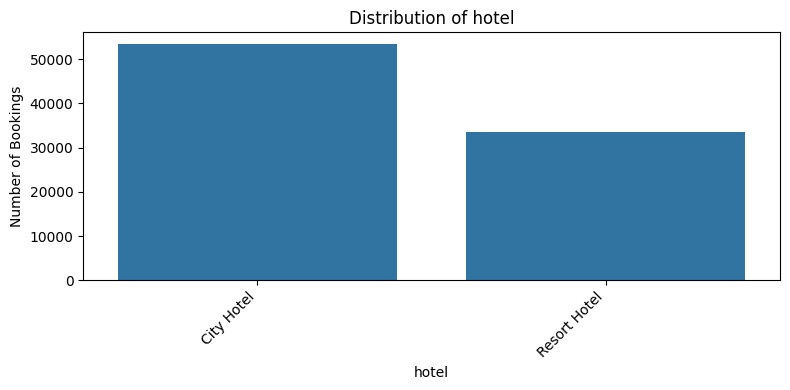

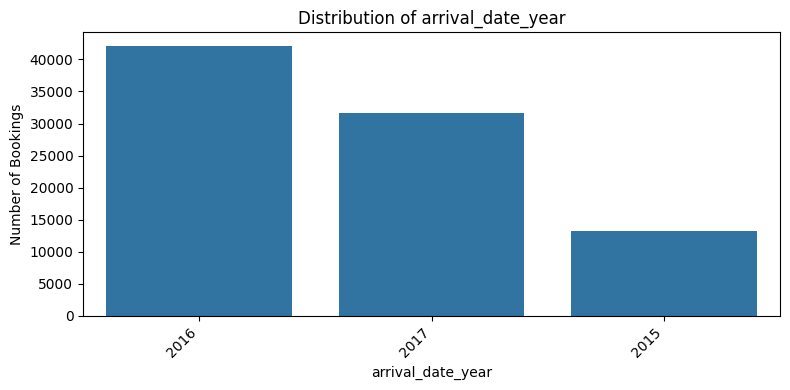

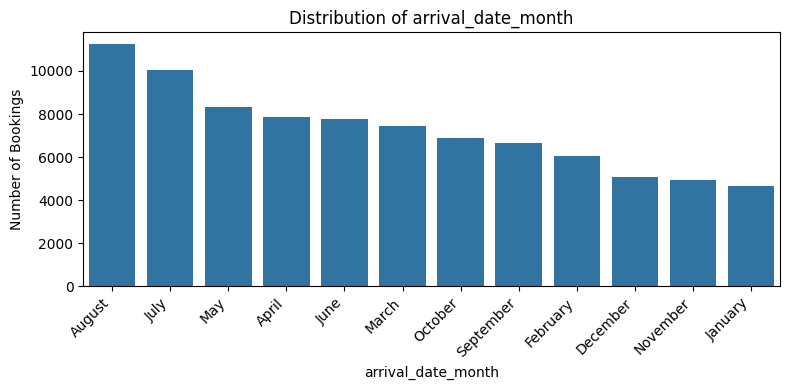

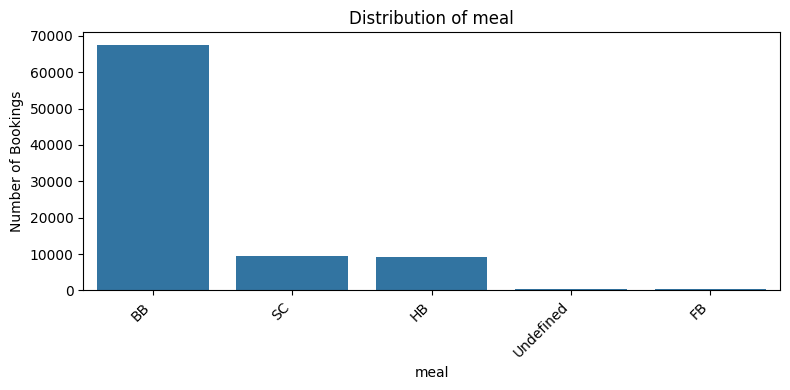

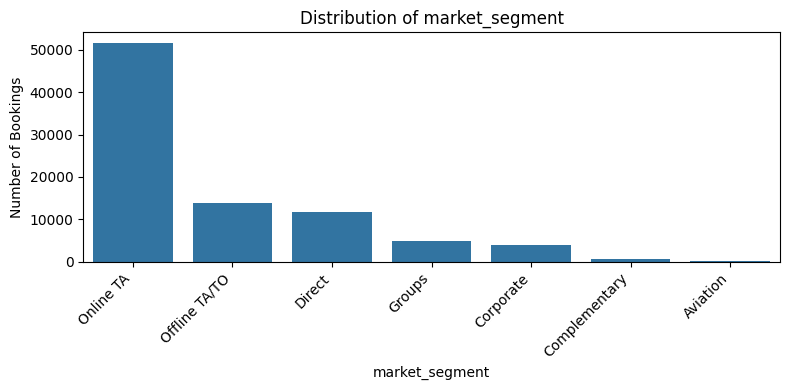

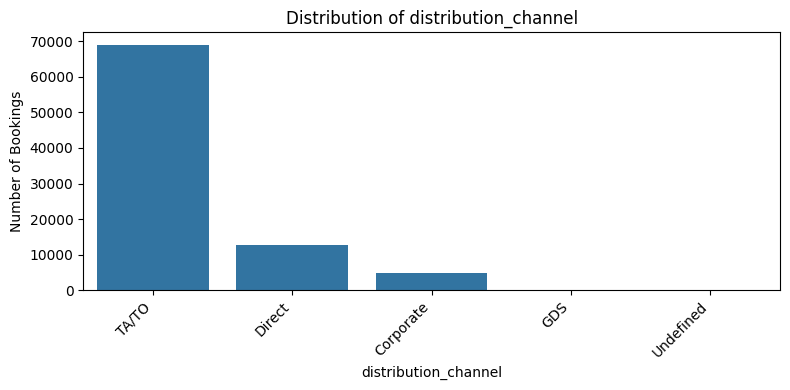

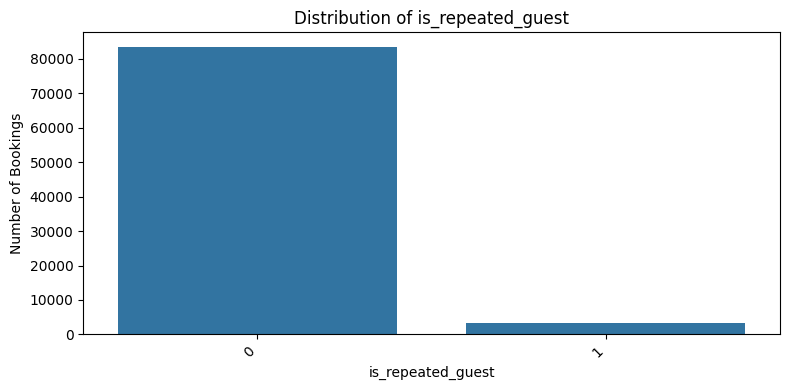

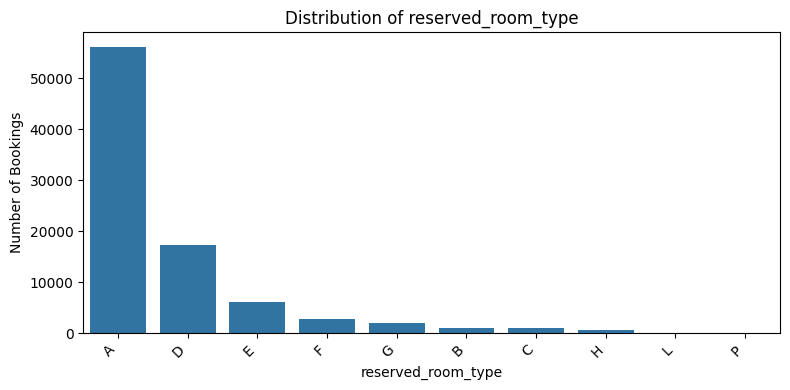

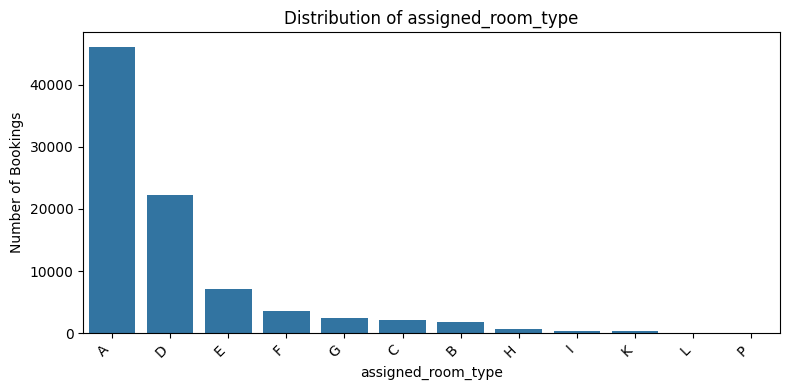

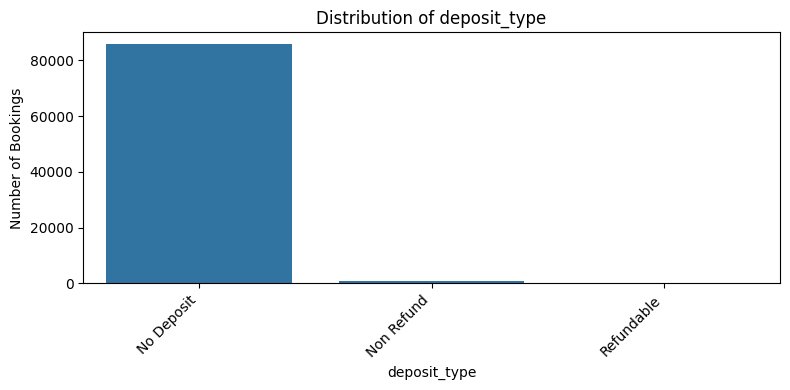

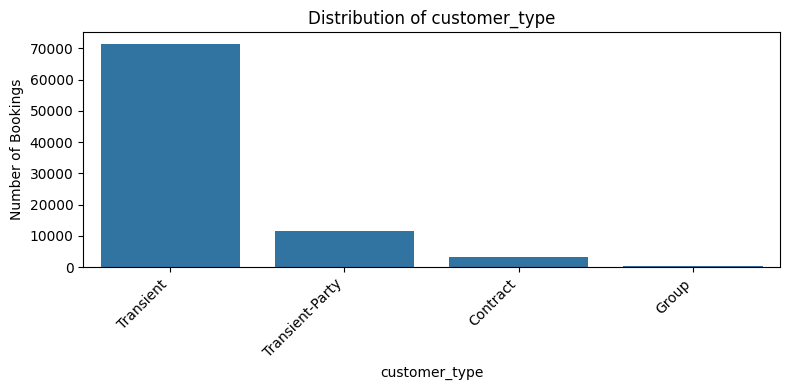

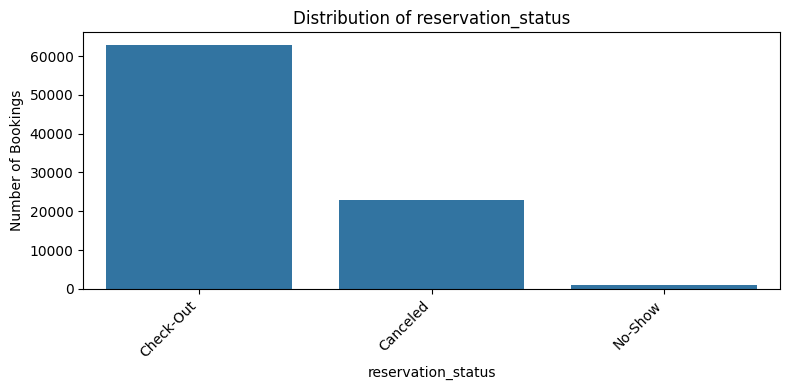

In [27]:
for col in low_cardinality_cols:
    plt.figure(figsize=(8, 4))

    order = df[col].value_counts().index

    sns.countplot(
        data=df,
        x=col,
        order=order
    )

    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Number of Bookings")
    plt.xticks(rotation=45, ha="right")

    plt.tight_layout()
    plt.show()

### Categorical Plot Findings

The categorical distributions confirm several patterns identified in the frequency tables.

`hotel` contains more City Hotel bookings than Resort Hotel bookings.

`arrival_date_year` is dominated by 2016, followed by 2017 and 2015. For `arrival_date_month`, August and July contain the largest numbers of bookings, while January and November contain comparatively fewer bookings.

`meal` is strongly dominated by BB, while SC and HB form much smaller groups. The `Undefined` and FB categories are rare.

`market_segment` is dominated by Online TA, followed by Offline TA/TO and Direct. Complementary and Aviation bookings occur relatively infrequently.

`distribution_channel` is heavily dominated by TA/TO, while GDS and Undefined occur very rarely.

Most bookings are from non-repeated guests, showing a strong imbalance in `is_repeated_guest`.

For both `reserved_room_type` and `assigned_room_type`, room type A is the dominant category, followed by room type D. Several room categories such as L and P are extremely rare.

`deposit_type` is overwhelmingly dominated by No Deposit, with relatively few Non Refund and Refundable bookings.

`customer_type` is dominated by Transient customers, while Group bookings represent only a very small proportion of observations.

`reservation_status` is dominated by Check-Out, followed by Canceled and No-Show. Because this variable describes the eventual outcome of the reservation, it has been identified as a leakage variable and must not be used as a predictive feature.

In [28]:
high_cardinality_cols = [
    col for col in categorical_cols
    if df[col].nunique(dropna=False) > 15
]

high_cardinality_cols

['arrival_date_week_number',
 'arrival_date_day_of_month',
 'country',
 'agent',
 'company']

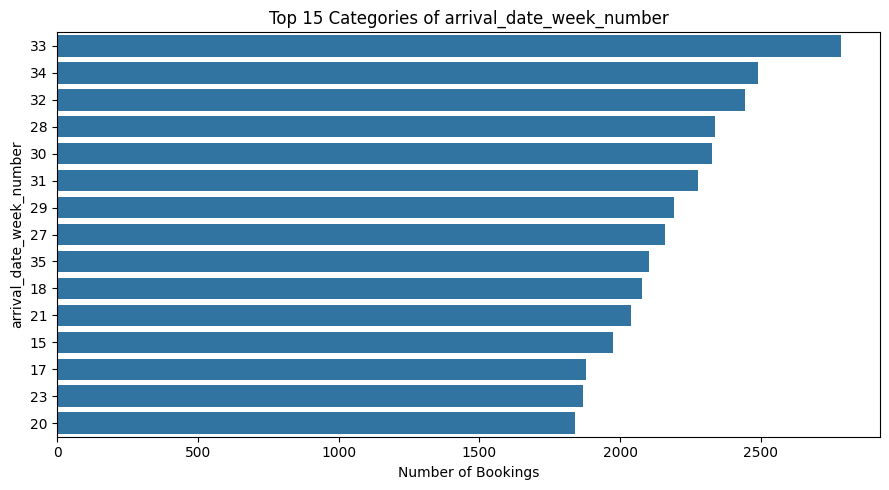

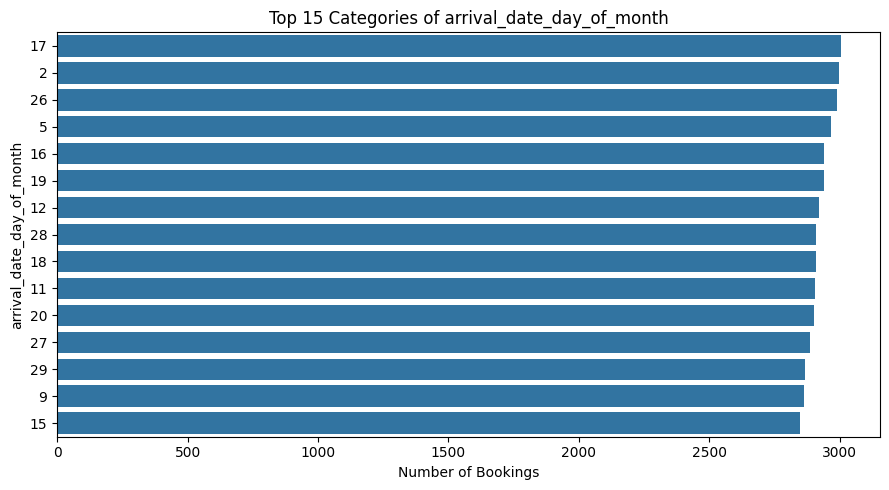

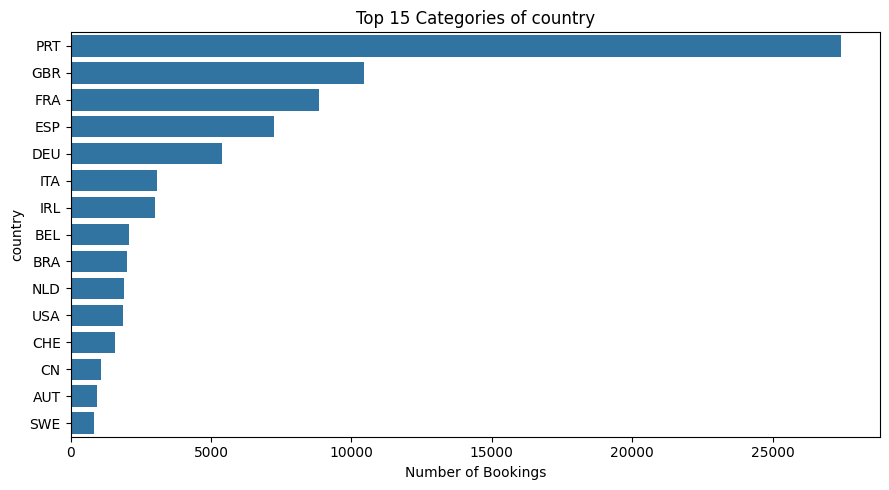

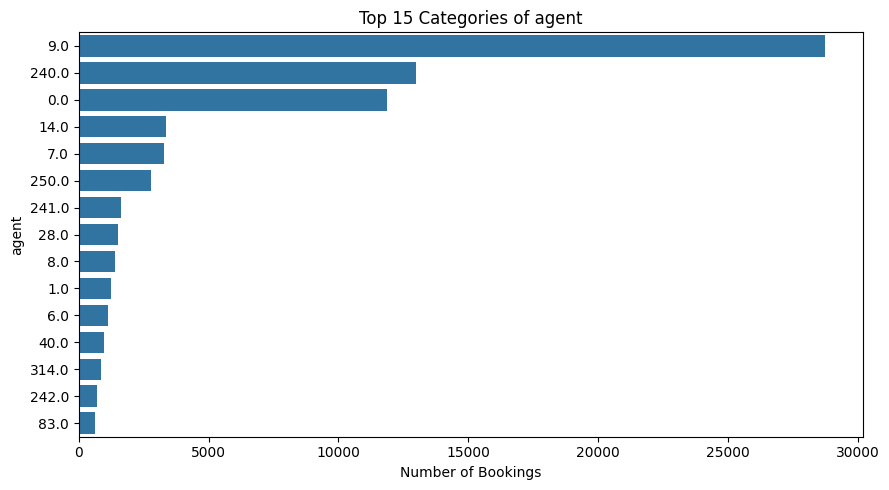

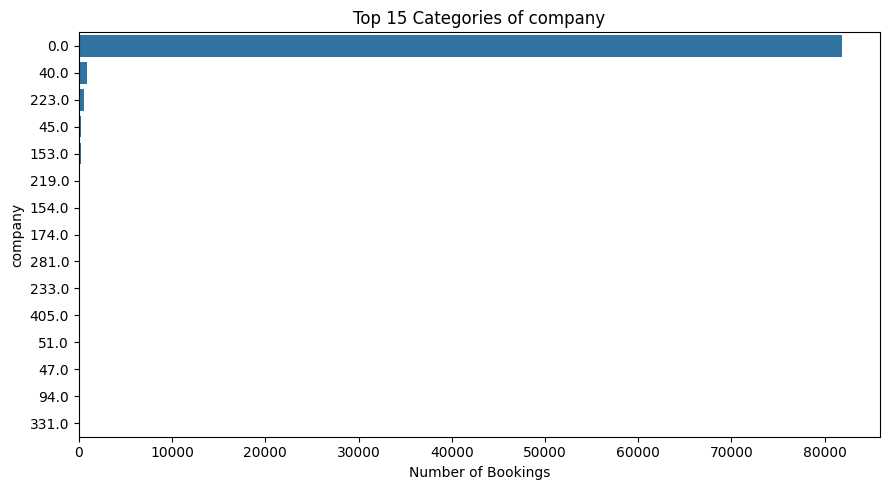

In [29]:
for col in high_cardinality_cols:
    top_categories = df[col].value_counts().head(15)

    plt.figure(figsize=(9, 5))

    sns.barplot(
        x=top_categories.values,
        y=top_categories.index.astype(str)
    )

    plt.title(f"Top 15 Categories of {col}")
    plt.xlabel("Number of Bookings")
    plt.ylabel(col)

    plt.tight_layout()
    plt.show()

### High-Cardinality Variable Findings

The high-cardinality categorical variables show different distribution patterns.

`arrival_date_week_number` contains 53 categories, with week 33 having the highest number of bookings. However, booking volume is distributed across many weeks rather than being dominated by a single category.

`arrival_date_day_of_month` contains 31 categories and shows a relatively even distribution across days.

`country` contains 177 categories and is highly fragmented. Portugal (`PRT`) is the dominant country, followed by the United Kingdom (`GBR`), France (`FRA`), Spain (`ESP`), and Germany (`DEU`). Most country categories occur infrequently. The presence of both `CN` and `CHN` also suggests a possible inconsistency in country-code representation that should be reviewed during preprocessing.

`agent` contains 333 unique IDs and is dominated by agent 9, followed by agent 240. A substantial number of records also use agent value 0, representing bookings not associated with an agent.

`company` contains 350 unique IDs but is overwhelmingly dominated by value 0, representing bookings not associated with a company. Most actual company IDs occur very rarely.

The high cardinality and sparsity of `country`, `agent`, and `company` may require careful treatment during later feature encoding.

## 4. Top 5 Univariate EDA Findings

### 1. Moderate class imbalance exists in the target variable

Approximately 72.41% of bookings were not cancelled, while 27.59% were cancelled. This indicates moderate class imbalance and suggests that model evaluation should consider metrics beyond accuracy.

### 2. Numerical variables are predominantly right-skewed

Several numerical features, including `previous_cancellations`, `previous_bookings_not_canceled`, `babies`, `days_in_waiting_list`, and `adr`, show strong positive skewness. Many are concentrated near zero with relatively few large observations.

### 3. Some numerical variables contain suspicious extreme values

`adr` ranges from -6.38 to 5400, including one negative observation and one isolated extreme maximum. Variables such as `adults`, `children`, and `babies` also contain unusually large values that should be reviewed during preprocessing.

### 4. Several categorical variables are strongly imbalanced

Variables such as `deposit_type`, `is_repeated_guest`, `company`, `distribution_channel`, and `customer_type` are dominated by a single category. For example, `No Deposit` accounts for approximately 98.68% of `deposit_type`.

### 5. High-cardinality categorical variables contain many rare categories

`country`, `agent`, and `company` contain 177, 333, and 350 categories respectively. Most of these categories represent less than 1% of the dataset, which may create sparse feature representations during modelling. A possible inconsistency was also observed in country coding because both `CN` and `CHN` appear in the dataset.

## 5. Conclusion

The univariate EDA identified several characteristics that should be considered during later preprocessing and modelling.

The target variable shows moderate class imbalance, while many numerical variables are strongly right-skewed and contain statistical outliers. Several categorical variables are highly imbalanced or contain a large number of rare categories.

Potential data-quality concerns include extreme `adr` values, unusual guest-count values, `Undefined` categorical labels, and possible inconsistent country coding.

No observations or categories were removed or transformed during this notebook. All identified issues are documented for later preprocessing review.